# Balancing Accuracy, Efficiency, and Robustness: An Empirical Study of Quantized CNN Models for Edge Deployment

**Model Architecture:** ResNet-18 (FP32 baseline vs. INT8 Post-Training Quantized)  
**Dataset:** MNIST Benchmark  
**Runtime:** Google Colab GPU (T4 recommended)

---

### Important — Enable GPU in Colab first
`Runtime` -> `Change runtime type` -> `Hardware accelerator` -> **T4 GPU** (or any available GPU), then `Save`.
This notebook trains and benchmarks the FP32 model on **GPU (cuda)**. The INT8 quantized model still runs on **CPU**, because PyTorch's `fbgemm`/`qnnpack` post-training quantization backends only support CPU inference — this is a PyTorch limitation, not something a GPU runtime changes, and matches how the ResNet-18 baseline was benchmarked.


In [1]:
# 0. Confirm GPU runtime is active (Colab)
import subprocess
try:
    print(subprocess.check_output(['nvidia-smi']).decode())
except Exception as e:
    print('nvidia-smi not found — no GPU attached. Go to Runtime > Change runtime type > GPU, then re-run.')


Thu Sep  3 15:13:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
import torchvision

print("PyTorch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("No GPU detected. In Colab: Runtime > Change runtime type > Hardware accelerator > GPU (T4), then Save and re-run all cells.")


PyTorch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA: 12.8
CUDA available: True
GPU: Tesla T4


In [3]:
import os
import time
import copy
import tempfile
import random
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets
from torchvision import transforms
from torchvision import models
from torch.utils.data import DataLoader
import torch.ao.quantization as quantization

print("All required standard libraries imported successfully.")


All required standard libraries imported successfully.


## 2. Random Seed Configuration for Academic Reproducibility

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {SEED} for Python, NumPy, and PyTorch.")


Random seed set to 42 for Python, NumPy, and PyTorch.


## 3. Hardware Compute Device Selection — forced to GPU

In [5]:
# Force GPU usage explicitly (raises if unavailable, instead of silently falling back to CPU)
assert torch.cuda.is_available(), "CUDA GPU not available — enable it via Runtime > Change runtime type."
device = torch.device("cuda")
print("Using device:", device)
print("Device name:", torch.cuda.get_device_name(0))


Using device: cuda
Device name: Tesla T4


## 4. Dataset Setup and Automated Downloading (MNIST)

In [6]:
data_dir = "./data/"
os.makedirs(data_dir, exist_ok=True)

raw_train_data = datasets.MNIST(root=data_dir, train=True, download=True)
raw_test_data = datasets.MNIST(root=data_dir, train=False, download=True)

print("MNIST dataset successfully downloaded and verified in ./data/")


100%|██████████| 9.91M/9.91M [00:02<00:00, 4.92MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.11MB/s]

MNIST dataset successfully downloaded and verified in ./data/


## 5. Defining Data Transformation Pipelines

In [7]:
IMAGE_SIZE = (224, 224)
MNIST_MEAN = (0.1307,)
MNIST_STD = (0.3081,)

train_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MNIST_MEAN, MNIST_STD)
])

test_transform = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MNIST_MEAN, MNIST_STD)
])

print("Data transformation pipelines defined successfully.")


Data transformation pipelines defined successfully.


## 6. PyTorch Dataset Instantiation

In [8]:
train_dataset = datasets.MNIST(root=data_dir, train=True, transform=train_transform, download=False)
test_dataset = datasets.MNIST(root=data_dir, train=False, transform=test_transform, download=False)

print(f"Train dataset created: {len(train_dataset)} samples")
print(f"Test dataset created: {len(test_dataset)} samples")


Train dataset created: 60000 samples
Test dataset created: 10000 samples


## 7. DataLoaders Construction — pinned memory for faster host-to-GPU transfer

In [9]:
BATCH_SIZE = 64

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Train loader initialized with batch size {BATCH_SIZE}")
print(f"Test loader initialized with batch size {BATCH_SIZE}")


Train loader initialized with batch size 64
Test loader initialized with batch size 64


## 8. Dataset Statistics and Metadata Summary

In [10]:
num_train_samples = len(train_dataset)
num_test_samples = len(test_dataset)

class_names = [str(i) for i in range(10)]
num_classes = len(class_names)

print("=== DATASET SUMMARY METADATA ===")
print(f"Training samples: {num_train_samples}")
print(f"Testing samples:  {num_test_samples}")
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")


=== DATASET SUMMARY METADATA ===
Training samples: 60000
Testing samples:  10000
Number of classes: 10
Class names: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


## 9. Data Visualization (Sample Image Inspection)

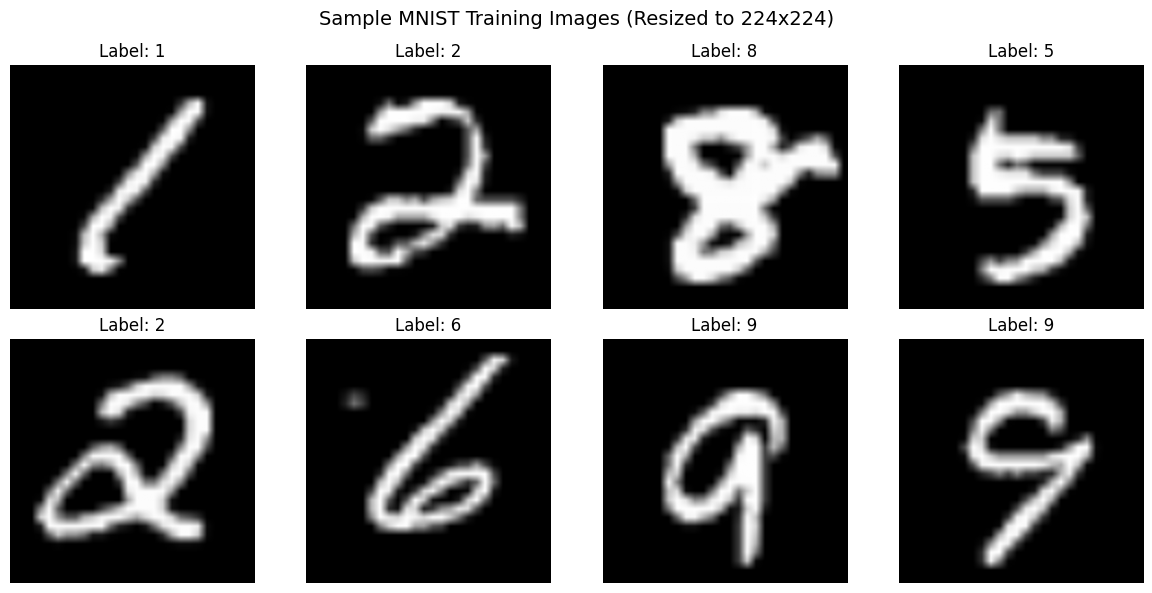

In [11]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    img_tensor = images[i][0] * MNIST_STD[0] + MNIST_MEAN[0]
    img_numpy = img_tensor.numpy()
    plt.imshow(img_numpy, cmap='gray')
    plt.title(f"Label: {labels[i].item()}", fontsize=12)
    plt.axis('off')

plt.suptitle("Sample MNIST Training Images (Resized to 224x224)", fontsize=14)
plt.tight_layout()
plt.show()


## 10. Model Architecture Selection and Initialization (ResNet-18)

In [12]:
# Instantiate a quantization-ready ResNet-18 without pre-trained weights.
# torchvision's plain models.resnet18() uses raw '+=' for its residual adds
# (out += identity in BasicBlock), which has NO INT8 kernel and crashes during
# PTQ conversion later. The torchvision.models.quantization variant uses
# FloatFunctional().add(...) internally instead, which IS INT8-safe, and
# already includes its own QuantStub/DeQuantStub.
from torchvision.models.quantization import resnet18 as qresnet18

model = qresnet18(weights=None, quantize=False)

print("Quantization-ready ResNet-18 architecture initialized without pretrained weights.")


Quantization-ready ResNet-18 architecture initialized without pretrained weights.


## 11. Adapting Convolutional Input Layer for Single-Channel Grayscale Images

In [13]:
# ResNet-18's stem conv is model.conv1: Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
old_conv = model.conv1

model.conv1 = nn.Conv2d(
    in_channels=1,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False
)

print("Modified model.conv1 to accept 1-channel grayscale input.")


Modified model.conv1 to accept 1-channel grayscale input.


## 12. Adapting Classification Head for 10 Target Classes

In [14]:
# ResNet-18's final layer is model.fc, a single Linear layer
in_features = model.fc.in_features

model.fc = nn.Linear(in_features, 10)

print(f"Modified model.fc: {in_features} input features -> {num_classes} output classes.")


Modified model.fc: 512 input features -> 10 output classes.


## 13. Transferring Model to Compute Device (GPU) & Architecture Inspection

In [15]:
model = model.to(device)

print(f"Model transferred to device: {device}")
print("Model is on GPU:", next(model.parameters()).is_cuda)
print("\n=== RESNET18 MODEL ARCHITECTURE ===")
print(model)


Model transferred to device: cuda
Model is on GPU: True

=== RESNET18 MODEL ARCHITECTURE ===
QuantizableResNet(
  (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): QuantizableBasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (add_relu): FloatFunctional(
        (activation_post_process): Identity()
      )
    )
    (1): QuantizableBasicBlock(
      (conv1): Conv2d(64, 64, 

## 14. Loss Function and Optimizer Setup

In [16]:
criterion = nn.CrossEntropyLoss()

LEARNING_RATE = 0.001
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(f"Loss criterion: CrossEntropyLoss | Optimizer: Adam (lr={LEARNING_RATE})")


Loss criterion: CrossEntropyLoss | Optimizer: Adam (lr=0.001)


## 15. Training and Evaluation Routines Implementation

In [17]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """Trains the model for one full epoch over the dataloader."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc


def evaluate_model(model, dataloader, device):
    """Evaluates the model and returns accuracy, predictions, and ground truth labels."""
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    accuracy = 100.0 * correct / total
    return accuracy, np.array(all_preds), np.array(all_targets)

print("Training and Evaluation helper functions successfully defined.")


Training and Evaluation helper functions successfully defined.


## 16. Training FP32 ResNet18 Model (3 Epochs) — runs on GPU

In [18]:
NUM_EPOCHS = 3

print("=== STARTING FP32 RESNET18 MODEL TRAINING ON", device, "===")

for epoch in range(1, NUM_EPOCHS + 1):
    start_time = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_acc, _, _ = evaluate_model(model, test_loader, device)

    elapsed_time = time.time() - start_time

    print(f"Epoch [{epoch}/{NUM_EPOCHS}] ({elapsed_time:.2f}s) | "
          f"Train Loss: {train_loss:.4f} | "
          f"Train Acc: {train_acc:.2f}% | "
          f"Test Acc: {test_acc:.2f}%")

print("=== FP32 MODEL TRAINING COMPLETED ===")


=== STARTING FP32 RESNET18 MODEL TRAINING ON cuda ===
Epoch [1/3] (185.89s) | Train Loss: 0.1030 | Train Acc: 96.87% | Test Acc: 97.94%
Epoch [2/3] (188.21s) | Train Loss: 0.0401 | Train Acc: 98.81% | Test Acc: 98.31%
Epoch [3/3] (187.98s) | Train Loss: 0.0311 | Train Acc: 99.00% | Test Acc: 99.17%
=== FP32 MODEL TRAINING COMPLETED ===


## 17. FP32 Model Clean Accuracy Evaluation

In [19]:
fp32_clean_acc, fp32_preds, fp32_targets = evaluate_model(model, test_loader, device)

print(f"Final Clean Accuracy (FP32 Model): {fp32_clean_acc:.2f}%")


Final Clean Accuracy (FP32 Model): 99.17%


## 18. Model Size and Inference Speed Benchmarking Helpers

In [20]:
def get_model_size_mb(model):
    """Measures serialized PyTorch model size in Megabytes (MB)."""
    with tempfile.NamedTemporaryFile(delete=False) as tmp_file:
        torch.save(model.state_dict(), tmp_file.name)
        size_bytes = os.path.getsize(tmp_file.name)
        tmp_path = tmp_file.name

    os.remove(tmp_path)
    size_mb = size_bytes / (1024.0 * 1024.0)
    return size_mb


def measure_inference_speed(model, dataloader, device, num_batches=50):
    """Measures average inference time per image in milliseconds (ms)."""
    model.eval()
    total_time = 0.0
    total_images = 0

    with torch.no_grad():
        for i, (images, _) in enumerate(dataloader):
            if i >= num_batches:
                break

            images = images.to(device)
            batch_size = images.size(0)

            if device.type == 'cuda':
                torch.cuda.synchronize()
            start_time = time.perf_counter()
            _ = model(images)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            end_time = time.perf_counter()

            total_time += (end_time - start_time)
            total_images += batch_size

    avg_ms_per_image = (total_time / total_images) * 1000.0
    return avg_ms_per_image

print("Model size and inference speed measurement functions defined successfully.")


Model size and inference speed measurement functions defined successfully.


## 19. Benchmarking FP32 Baseline Model Size & Latency (on GPU)

In [21]:
fp32_model_size_mb = get_model_size_mb(model)
fp32_inference_time_ms = measure_inference_speed(model, test_loader, device)

print(f"FP32 Model Size:        {fp32_model_size_mb:.2f} MB")
print(f"FP32 Inference Latency: {fp32_inference_time_ms:.4f} ms per image (on {device})")


FP32 Model Size:        42.71 MB
FP32 Inference Latency: 0.7978 ms per image (on cuda)


## 20. Post-Training Quantization (PTQ) Setup

**Note:** PyTorch's eager-mode static PTQ (`fbgemm` backend) only runs on **CPU**. The quantized model below is therefore evaluated on CPU while the FP32 model above ran on GPU — this reflects PyTorch's own backend restriction, not a code choice you can configure around.

**Also note:** `torchvision.models.quantization.resnet18` already contains its own internal `QuantStub`/`DeQuantStub` (built into its `forward()`), so — unlike a plain `torchvision.models.resnet18` — it does **not** need a custom wrapper class here. Adding one anyway would apply quantization twice and crash.

In [22]:
# Copy the model to CPU for quantization (fbgemm PTQ backend requires CPU)
model_to_quantize = copy.deepcopy(model).to('cpu')
model_to_quantize.eval()

print("Model copy prepared on CPU for quantization (no extra wrapper needed).")


Model copy prepared on CPU for quantization (no extra wrapper needed).


## 21. Fusing Layers, Attaching Quantization Observers & Calibration

In [23]:
model_to_quantize.qconfig = quantization.get_default_qconfig('fbgemm')

# Fuse Conv+BN+ReLU blocks where possible before observing/calibrating.
# This quantization-ready model class supports fuse_model() directly and it
# typically improves INT8 accuracy versus quantizing unfused layers.
model_to_quantize.fuse_model()

prepared_model = quantization.prepare(model_to_quantize, inplace=False)
prepared_model.eval()

print("Quantization observers attached. Calibrating over 10 training batches...")

with torch.no_grad():
    for i, (images, _) in enumerate(train_loader):
        if i >= 10:
            break
        prepared_model(images.to('cpu'))

print("Quantization calibration successfully completed!")


Quantization observers attached. Calibrating over 10 training batches...


/tmp/ipykernel_1913/548333023.py:8: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  prepared_model = quantization.prepare(model_to_quantize, inplace=False)
/usr/local/lib/python3.13/dist-packages/torch/ao/quantization/observer.py:1039: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in 

Quantization calibration successfully completed!


## 22. Converting to INT8 and Benchmarking Quantized Performance

In [24]:
quantized_model = quantization.convert(prepared_model, inplace=False)
print("Model successfully converted to INT8 Quantized Format!")

int8_clean_acc, _, _ = evaluate_model(quantized_model, test_loader, device=torch.device('cpu'))
int8_model_size_mb = get_model_size_mb(quantized_model)
int8_inference_time_ms = measure_inference_speed(quantized_model, test_loader, device=torch.device('cpu'))

compression_ratio = fp32_model_size_mb / int8_model_size_mb

print("=== INT8 QUANTIZED MODEL METRICS ===")
print(f"INT8 Clean Accuracy:     {int8_clean_acc:.2f}%")
print(f"INT8 Model Size:         {int8_model_size_mb:.2f} MB")
print(f"INT8 Inference Latency:  {int8_inference_time_ms:.4f} ms/image")
print(f"Compression Ratio:       {compression_ratio:.2f}x")


/tmp/ipykernel_1913/570391543.py:1: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = quantization.convert(prepared_model, inplace=False)


Model successfully converted to INT8 Quantized Format!
=== INT8 QUANTIZED MODEL METRICS ===
INT8 Clean Accuracy:     99.13%
INT8 Model Size:         10.78 MB
INT8 Inference Latency:  33.0200 ms/image
Compression Ratio:       3.96x


## 23. Implementing Manual FGSM Adversarial Attack Algorithm

In [26]:
def fgsm_attack(image, epsilon, data_grad):
    """Generates Fast Gradient Sign Method (FGSM) adversarial images."""
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    return perturbed_image


def evaluate_fgsm(surrogate_model, eval_model, dataloader, epsilon, surrogate_device, eval_device, max_batches=30):
    """Evaluates model accuracy under FGSM adversarial attack using surrogate gradients."""
    surrogate_model.eval()
    eval_model.eval()

    correct = 0
    total = 0
    criterion = nn.CrossEntropyLoss()

    for i, (images, labels) in enumerate(dataloader):
        if i >= max_batches:
            break

        images_surr = images.to(surrogate_device)
        labels_surr = labels.to(surrogate_device)
        images_surr.requires_grad = True

        outputs_surr = surrogate_model(images_surr)
        loss = criterion(outputs_surr, labels_surr)

        surrogate_model.zero_grad()
        loss.backward()

        data_grad = images_surr.grad.data
        perturbed_images = fgsm_attack(images_surr, epsilon, data_grad)

        with torch.no_grad():
            perturbed_eval = perturbed_images.to(eval_device)
            labels_eval = labels.to(eval_device)

            outputs_eval = eval_model(perturbed_eval)
            _, predicted = torch.max(outputs_eval.data, 1)

            total += labels_eval.size(0)
            correct += (predicted == labels_eval).sum().item()

    accuracy = 100.0 * correct / total
    return accuracy

print("Manual FGSM attack and evaluation helper functions defined.")

Manual FGSM attack and evaluation helper functions defined.


## 24. Benchmarking Adversarial Robustness (FP32 vs INT8 under FGSM $\epsilon=0.20$)

In [27]:
EPSILON = 0.20

print(f"Evaluating adversarial robustness under FGSM attack (epsilon = {EPSILON})...")

fp32_fgsm_acc = evaluate_fgsm(
    surrogate_model=model,
    eval_model=model,
    dataloader=test_loader,
    epsilon=EPSILON,
    surrogate_device=device,
    eval_device=device
)

int8_fgsm_acc = evaluate_fgsm(
    surrogate_model=model,
    eval_model=quantized_model,
    dataloader=test_loader,
    epsilon=EPSILON,
    surrogate_device=device,
    eval_device=torch.device('cpu')
)

print(f"FP32 Model FGSM Accuracy (eps={EPSILON}): {fp32_fgsm_acc:.2f}%")
print(f"INT8 Model FGSM Accuracy (eps={EPSILON}): {int8_fgsm_acc:.2f}%")


Evaluating adversarial robustness under FGSM attack (epsilon = 0.2)...
FP32 Model FGSM Accuracy (eps=0.2): 78.75%
INT8 Model FGSM Accuracy (eps=0.2): 78.70%


## 25. Results Aggregation & Export (`results/results_resnet18.csv`)

In [28]:
results_data = {
    "Model": ["ResNet18 FP32", "ResNet18 INT8"],
    "Precision": ["FP32", "INT8"],
    "Clean Accuracy": [f"{fp32_clean_acc:.2f}%", f"{int8_clean_acc:.2f}%"],
    "FGSM Accuracy": [f"{fp32_fgsm_acc:.2f}%", f"{int8_fgsm_acc:.2f}%"],
    "Model Size (MB)": [round(fp32_model_size_mb, 2), round(int8_model_size_mb, 2)],
    "Inference Time (ms)": [round(fp32_inference_time_ms, 4), round(int8_inference_time_ms, 4)],
    "Compression Ratio": [1.00, round(compression_ratio, 2)]
}

results_df = pd.DataFrame(results_data)

print("=== EXPERIMENTAL RESULTS COMPARISON TABLE ===")
print(results_df.to_string(index=False))

results_dir = "./results/"
os.makedirs(results_dir, exist_ok=True)
csv_path = os.path.join(results_dir, "results_resnet18.csv")
results_df.to_csv(csv_path, index=False)

print(f"Results table successfully saved to: {csv_path}")


=== EXPERIMENTAL RESULTS COMPARISON TABLE ===
        Model Precision Clean Accuracy FGSM Accuracy  Model Size (MB)  Inference Time (ms)  Compression Ratio
ResNet18 FP32      FP32         99.17%        78.75%            42.71               0.7978               1.00
ResNet18 INT8      INT8         99.13%        78.70%            10.78              33.0200               3.96
Results table successfully saved to: ./results/results_resnet18.csv


## 26. Experimental Metrics Visualizations (Graphs)

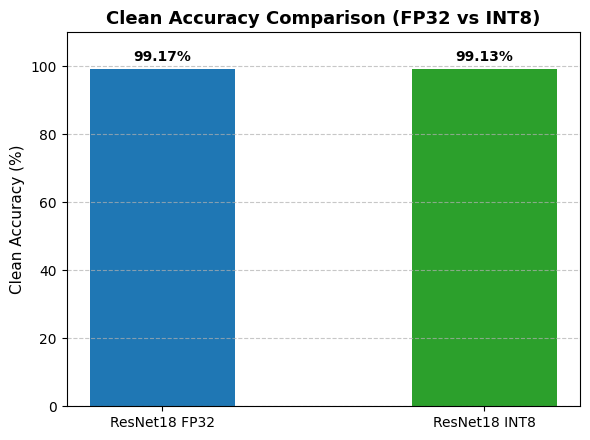

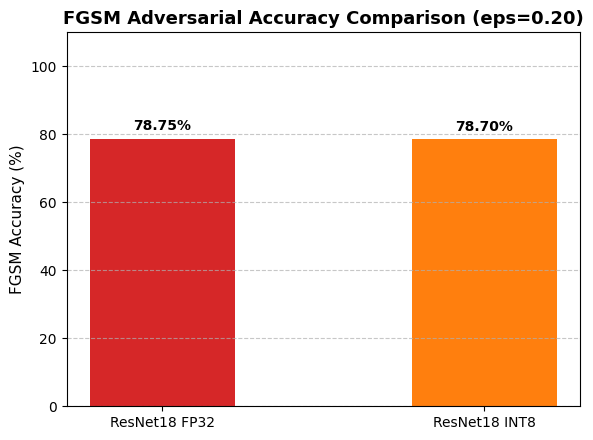

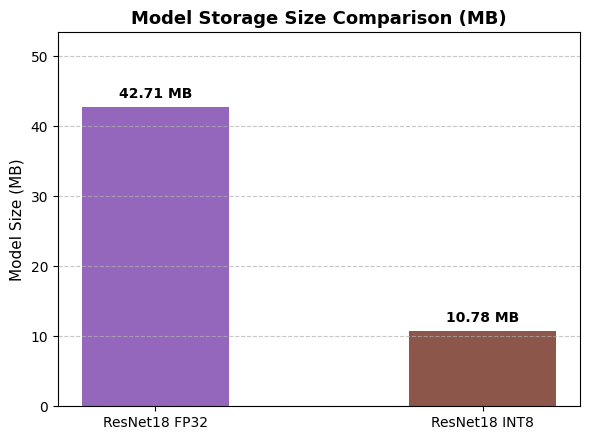

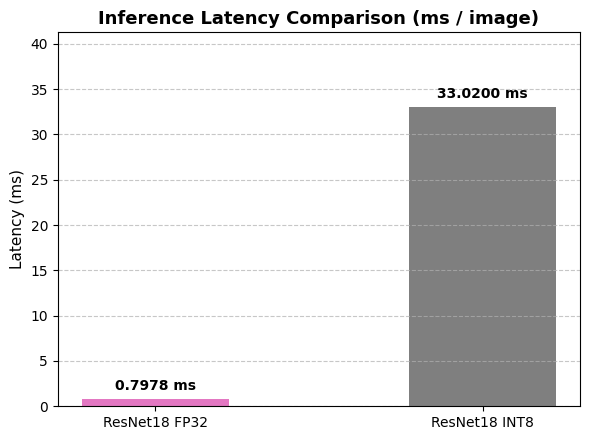

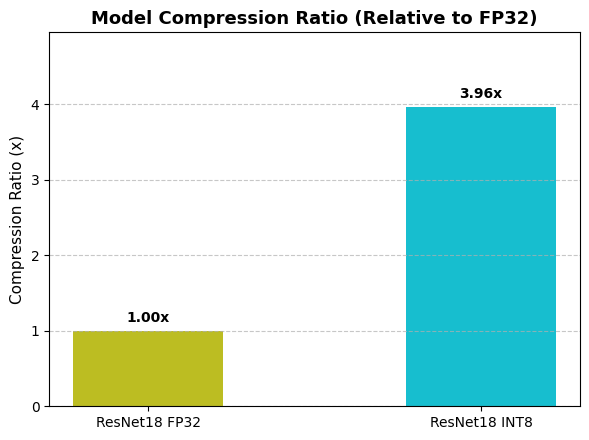

All 5 comparison graphs successfully generated and saved to ./results/


In [29]:
models_labels = ["ResNet18 FP32", "ResNet18 INT8"]

# 1. Clean Accuracy Graph
plt.figure(figsize=(6, 4.5))
bars = plt.bar(models_labels, [fp32_clean_acc, int8_clean_acc], color=['#1f77b4', '#2ca02c'], width=0.45)
plt.title("Clean Accuracy Comparison (FP32 vs INT8)", fontsize=13, fontweight='bold')
plt.ylabel("Clean Accuracy (%)", fontsize=11)
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "resnet18_clean_accuracy_comparison.png"), dpi=300)
plt.show()

# 2. FGSM Accuracy Graph
plt.figure(figsize=(6, 4.5))
bars = plt.bar(models_labels, [fp32_fgsm_acc, int8_fgsm_acc], color=['#d62728', '#ff7f0e'], width=0.45)
plt.title("FGSM Adversarial Accuracy Comparison (eps=0.20)", fontsize=13, fontweight='bold')
plt.ylabel("FGSM Accuracy (%)", fontsize=11)
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1.5, f"{yval:.2f}%", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "resnet18_fgsm_accuracy_comparison.png"), dpi=300)
plt.show()

# 3. Model Size Graph
plt.figure(figsize=(6, 4.5))
sizes_mb = [fp32_model_size_mb, int8_model_size_mb]
bars = plt.bar(models_labels, sizes_mb, color=['#9467bd', '#8c564b'], width=0.45)
plt.title("Model Storage Size Comparison (MB)", fontsize=13, fontweight='bold')
plt.ylabel("Model Size (MB)", fontsize=11)
plt.ylim(0, max(sizes_mb) * 1.25)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(sizes_mb)*0.02), f"{yval:.2f} MB", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "resnet18_model_size_comparison.png"), dpi=300)
plt.show()

# 4. Inference Time Graph
plt.figure(figsize=(6, 4.5))
latencies_ms = [fp32_inference_time_ms, int8_inference_time_ms]
bars = plt.bar(models_labels, latencies_ms, color=['#e377c2', '#7f7f7f'], width=0.45)
plt.title("Inference Latency Comparison (ms / image)", fontsize=13, fontweight='bold')
plt.ylabel("Latency (ms)", fontsize=11)
plt.ylim(0, max(latencies_ms) * 1.25)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(latencies_ms)*0.02), f"{yval:.4f} ms", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "resnet18_inference_time_comparison.png"), dpi=300)
plt.show()

# 5. Compression Ratio Graph
plt.figure(figsize=(6, 4.5))
comp_ratios = [1.0, compression_ratio]
bars = plt.bar(models_labels, comp_ratios, color=['#bcbd22', '#17becf'], width=0.45)
plt.title("Model Compression Ratio (Relative to FP32)", fontsize=13, fontweight='bold')
plt.ylabel("Compression Ratio (x)", fontsize=11)
plt.ylim(0, max(comp_ratios) * 1.25)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(comp_ratios)*0.02), f"{yval:.2f}x", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, "resnet18_compression_ratio_comparison.png"), dpi=300)
plt.show()

print("All 5 comparison graphs successfully generated and saved to ./results/")


## 27. Final Research Summary & Academic Reproducibility Metadata

In [30]:
import sys

accuracy_drop = fp32_clean_acc - int8_clean_acc
size_reduction_pct = ((fp32_model_size_mb - int8_model_size_mb) / fp32_model_size_mb) * 100.0
speedup_factor = fp32_inference_time_ms / int8_inference_time_ms if int8_inference_time_ms > 0 else 1.0

print("==============================================================")
print("       PILOT RESEARCH EXPERIMENT SUMMARY — RESNET18       ")
print("==============================================================")
print(f"1. FP32 Clean Accuracy:        {fp32_clean_acc:.2f}%")
print(f"2. INT8 Clean Accuracy:        {int8_clean_acc:.2f}%")
print(f"3. Accuracy Drop:              {accuracy_drop:.2f}%")
print(f"4. FP32 FGSM Robustness:       {fp32_fgsm_acc:.2f}%")
print(f"5. INT8 FGSM Robustness:       {int8_fgsm_acc:.2f}%")
print(f"6. FP32 Model Size:            {fp32_model_size_mb:.2f} MB")
print(f"7. INT8 Model Size:            {int8_model_size_mb:.2f} MB")
print(f"8. Storage Size Reduction:     {size_reduction_pct:.2f}%")
print(f"9. Compression Ratio:          {compression_ratio:.2f}x")
print(f"10. FP32 Inference Speed:      {fp32_inference_time_ms:.4f} ms/image (GPU)")
print(f"11. INT8 Inference Speed:      {int8_inference_time_ms:.4f} ms/image (CPU)")
print(f"12. Inference Speedup Factor:  {speedup_factor:.2f}x")
print("==============================================================")

print("\n=== ACADEMIC REPRODUCIBILITY METADATA ===")
print(f"Python Version:     {sys.version.split()[0]}")
print(f"PyTorch Version:    {torch.__version__}")
print(f"TorchVision Version:{transforms.__file__}")
print(f"Compute Device:     {device}")
print(f"Random Seed:        {SEED}")
print(f"Timestamp:          {datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=========================================")


       PILOT RESEARCH EXPERIMENT SUMMARY — RESNET18       
1. FP32 Clean Accuracy:        99.17%
2. INT8 Clean Accuracy:        99.13%
3. Accuracy Drop:              0.04%
4. FP32 FGSM Robustness:       78.75%
5. INT8 FGSM Robustness:       78.70%
6. FP32 Model Size:            42.71 MB
7. INT8 Model Size:            10.78 MB
8. Storage Size Reduction:     74.75%
9. Compression Ratio:          3.96x
10. FP32 Inference Speed:      0.7978 ms/image (GPU)
11. INT8 Inference Speed:      33.0200 ms/image (CPU)
12. Inference Speedup Factor:  0.02x

=== ACADEMIC REPRODUCIBILITY METADATA ===
Python Version:     3.13.15
PyTorch Version:    2.11.0+cu128
TorchVision Version:/usr/local/lib/python3.13/dist-packages/torchvision/transforms/__init__.py
Compute Device:     cuda
Random Seed:        42
Timestamp:          2026-09-03 15:40:22
